# HITL : Human In The Loop 

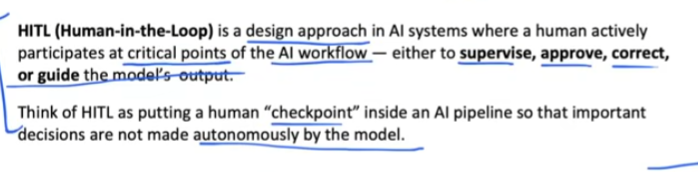

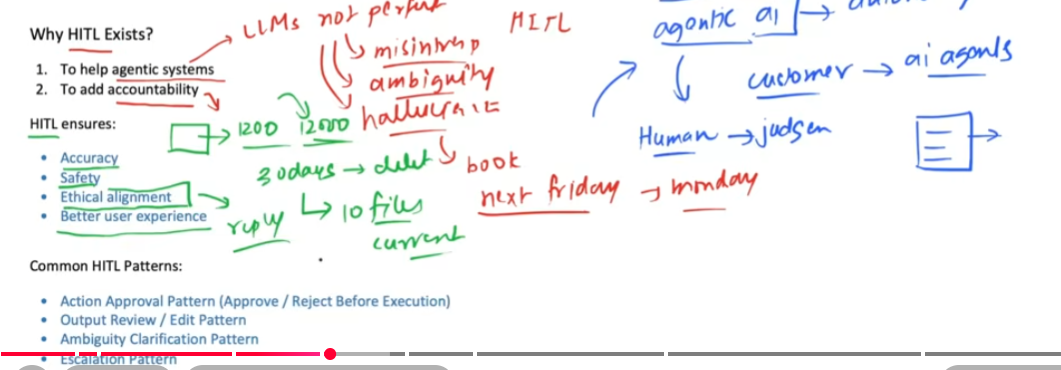

# Example workflow

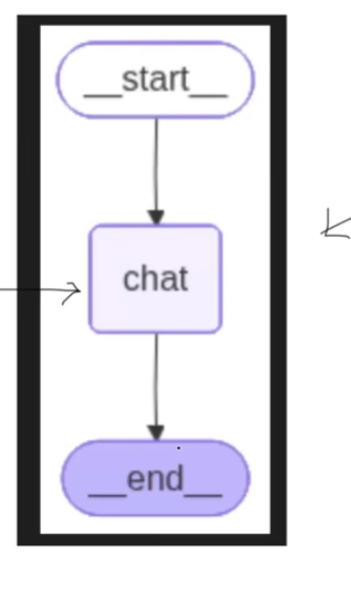

In [1]:
from typing import Annotated

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [2]:
load_dotenv()
llm = ChatOllama(model="qwen3", temperature=0)
embeddings = OllamaEmbeddings(model="nomic-embed-text")

In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [5]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

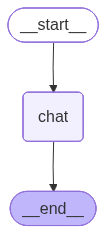

In [6]:
app

In [13]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [14]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='9bdf9163-e479-4e19-9059-a6a2df6ad450'),
  AIMessage(content='Gradient descent is like a simple way to find the lowest point in a hilly landscape, but you can only see the immediate area around you. Here\'s how it works:\n\n1. **Imagine you\'re hiking down a mountain** and want to reach the bottom. You can\'t see the whole mountain, just the slope beneath your feet.  \n2. **You check the slope** (called the "gradient") at your current spot. The gradient tells you which direction is the steepest downhill.  \n3. **You take a step** in the opposite direction of the slope (since you want to go down, not up). The size of your step is controlled by a "learning rate" — too big, and you might overshoot the bottom; too small, and it takes forever to get there.  \n4. **Repeat this process** — check the slope, take a step, adjust your step size — until you reach the 

In [15]:
message = result['__interrupt__'][0].value
message


{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [16]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [17]:
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [18]:
print(final_result["messages"][-1].content)

Imagine you're on a mountain and want to reach the **lowest point** (like the bottom of a valley). You can’t see the whole mountain, just the ground beneath your feet. Here’s how you’d do it:

1. **Look at the slope** (the "gradient") around you. It tells you which direction is the steepest downhill.  
2. **Take a step** in that direction. The size of your step is like a "learning rate" — too big, and you might overshoot the bottom; too small, and it takes forever.  
3. **Repeat** this: check the slope, step downhill, adjust your step size. Over time, you’ll get closer and closer to the bottom.  

In simple terms, **gradient descent** is a way to find the **lowest point** (or best solution) by always moving in the direction that makes things "better" (like going downhill), step by step. 🏔️
